<a href="https://colab.research.google.com/github/mariaaapetrovskaya/Developing-a-Model-for-Automatic-Gesture-Recognition/blob/main/Gemma_experiment_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Истинных меток в CSV: 147
Первые 5 строк истинных меток:
                                           file_name  \
0  video-output-5E0D6224-9912-4EE4-80AB-152B5B67E...   
1  video-output-AF84B477-C556-4888-BAB0-866AA2994...   
2  video-output-01BDAB79-CA08-42A0-8024-163AB9AC1...   
3  video-output-4715D551-BD20-4645-9A06-22E11466D...   
4  video-output-B387E2B1-5A74-4AB0-95C6-9FD3F1C43...   

                        label  
0            речевое действие  
1            речевое действие  
2  жест внутреннего состояния  
3           риторический жест  
4            речевое действие  

Загрузите ваш CSV-файл с предсказаниями
Файл должен содержать колонки: file_name, predicted_type


Saving predictions.csv - Лист1 (1).csv to predictions.csv - Лист1 (1).csv
Предсказаний: 98
Первые 5 строк предсказаний:
                                      file_name              predicted_type
0  gdrive_1-yQJpvbh21sP0V9FHuDUjRISDREkKYaS.mp4           риторический жест
1  gdrive_1-N8dNPMRremIsDpHMHR78g4ej0rWKV4m.mp4           риторический жест
2  gdrive_1Kv1QlHa9CdHj0dPmO7NiKObt4KOUv71G.mp4  жест внутреннего состояния
3  gdrive_11ETGjdwMGGV52E1yq38YJ4unPqTKrJ-S.mp4  жест внутреннего состояния
4  gdrive_1sqCnrECFLKFK2nP7JS13nY5bhW3d0cdC.mp4  жест внутреннего состояния

Сопоставлено видео: 98 из 98 предсказанных

 Accuracy: 0.1735 (17.35%)

Classification Report:
                            precision    recall  f1-score   support

         дейктический жест       1.00      0.12      0.22         8
         декоративный жест       0.00      0.00      0.00         2
жест внутреннего состояния       0.15      0.36      0.21        11
      изобразительный жест       1.00      0.03      0.

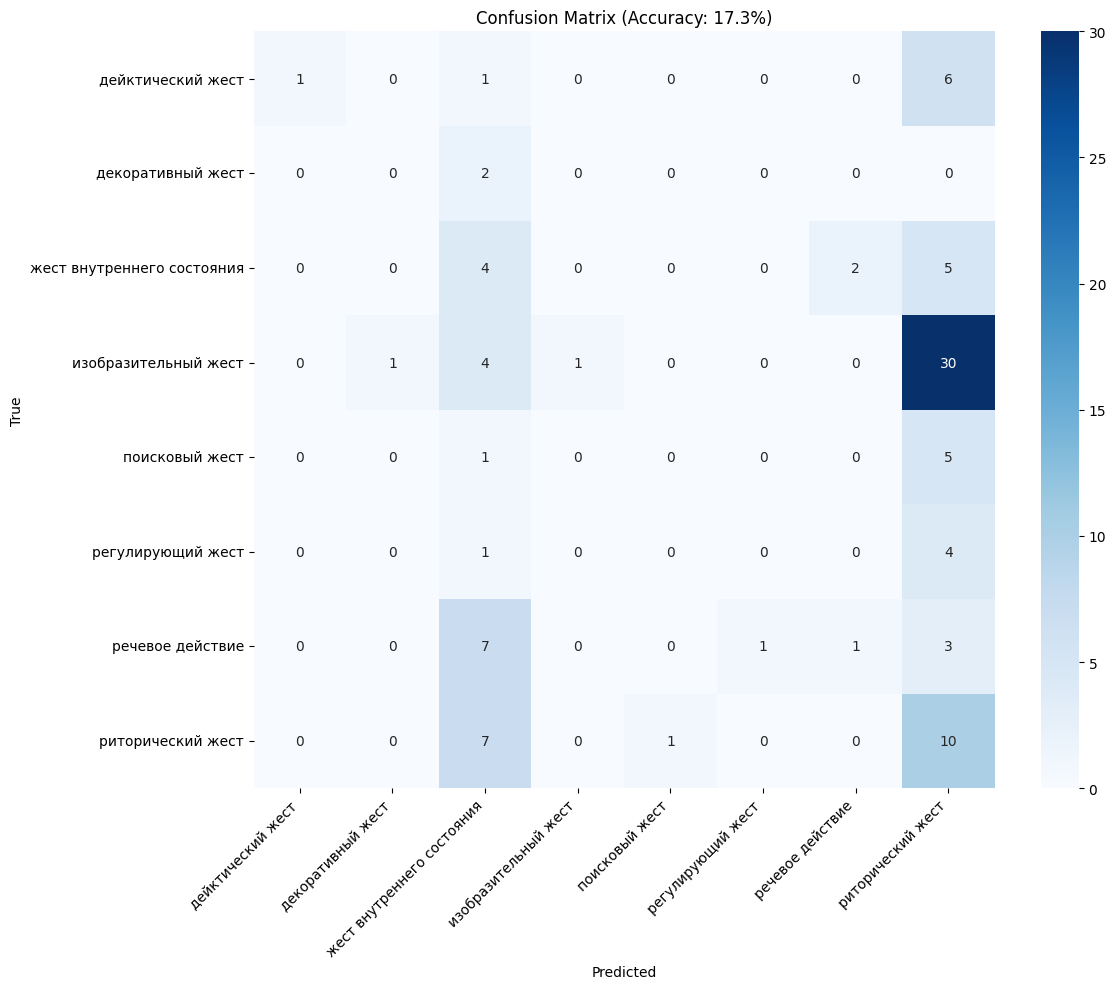


Per-class accuracy:
  дейктический жест: 12.5% (8 samples)
  декоративный жест: 0.0% (2 samples)
  жест внутреннего состояния: 36.4% (11 samples)
  изобразительный жест: 2.8% (36 samples)
  поисковый жест: 0.0% (6 samples)
  регулирующий жест: 0.0% (5 samples)
  речевое действие: 8.3% (12 samples)
  риторический жест: 55.6% (18 samples)

Полная таблица предсказаний (истинный тип → предсказанный):
                                       file_name                       label              predicted_type
0   gdrive_1-yQJpvbh21sP0V9FHuDUjRISDREkKYaS.mp4           дейктический жест           риторический жест
1   gdrive_1-N8dNPMRremIsDpHMHR78g4ej0rWKV4m.mp4              поисковый жест           риторический жест
2   gdrive_1Kv1QlHa9CdHj0dPmO7NiKObt4KOUv71G.mp4           риторический жест  жест внутреннего состояния
3   gdrive_11ETGjdwMGGV52E1yq38YJ4unPqTKrJ-S.mp4            речевое действие  жест внутреннего состояния
4   gdrive_1sqCnrECFLKFK2nP7JS13nY5bhW3d0cdC.mp4           регулирующий же

In [2]:
import pandas as pd
import io
import requests
import re
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

url = "https://huggingface.co/datasets/mapetrovska/gesturedataset_1/resolve/main/metadata.csv?download=1"
response = requests.get(url)
df_true = pd.read_csv(io.StringIO(response.text))
print(f"Истинных меток в CSV: {len(df_true)}")
print("Первые 5 строк истинных меток:")
print(df_true.head())

def normalize_filename(fname):
    if not fname.startswith("gdrive_") and re.match(r'^[0-9a-zA-Z_-]+\.mp4$', fname):
        return f"gdrive_{fname}"
    return fname

df_true['file_name_norm'] = df_true['file_name'].apply(normalize_filename)


print("\n" + "="*50)
print("Загрузите ваш CSV-файл с предсказаниями")
print("Файл должен содержать колонки: file_name, predicted_type")
print("="*50)
uploaded = files.upload()
pred_filename = list(uploaded.keys())[0]
df_pred = pd.read_csv(pred_filename, sep=None, engine='python')
print(f"Предсказаний: {len(df_pred)}")
print("Первые 5 строк предсказаний:")
print(df_pred.head())


df_merged = df_pred.merge(df_true[['file_name_norm', 'label']], left_on='file_name', right_on='file_name_norm', how='inner')
print(f"\nСопоставлено видео: {len(df_merged)} из {len(df_pred)} предсказанных")

if len(df_merged) == 0:
    print("\n Не удалось сопоставить имена. Проверьте:")
    print("Примеры имён в предсказаниях:", df_pred['file_name'].head().tolist())
    print("Примеры нормализованных имён в истинных метках:", df_true['file_name_norm'].head().tolist())
    print("\nВозможно, в вашем CSV другой разделитель. Укажите его явно в pd.read_csv(..., sep='\\t')")
else:
    y_true = df_merged['label']
    y_pred = df_merged['predicted_type']

    acc = accuracy_score(y_true, y_pred)
    print(f"\n Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Confusion matrix
    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix (Accuracy: {acc*100:.1f}%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()


    print("\nPer-class accuracy:")
    for label in labels:
        mask = (y_true == label)
        if mask.sum() > 0:
            class_acc = (y_pred[mask] == label).sum() / mask.sum()
            print(f"  {label}: {class_acc*100:.1f}% ({mask.sum()} samples)")

print("\nПолная таблица предсказаний (истинный тип → предсказанный):")
print(df_merged[['file_name', 'label', 'predicted_type']].to_string())
df_merged[['file_name', 'label', 'predicted_type']].to_csv("predictions_vs_true.csv", index=False)
print("Таблица сохранена в predictions_vs_true.csv")